In [ ]:
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torch
from PIL import Image
import os

In [ ]:
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()

token = os.getenv("HF_TOKEN")
if token:
    login(token=token)
else:
    print("HF_TOKEN not found")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [29]:
# Custom PyTorch Dataset
class SidewalkDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.data = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        image = sample['pixel_values']  # Извлекаем изображение
        mask = sample['label']         # Извлекаем маску

        # Применяем преобразования
        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        # Маска должна быть одноканальной
        mask = mask[0, :, :].unsqueeze(0) if mask.ndim == 3 else mask.unsqueeze(0)

        return image, mask

In [30]:
from datasets import load_dataset
hf_dataset = load_dataset("segments/sidewalk-semantic", split="train")

In [31]:
print(hf_dataset[0])

{'pixel_values': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1920x1080 at 0x25D210059D0>, 'label': <PIL.PngImagePlugin.PngImageFile image mode=L size=1920x1080 at 0x25D210045F0>}


In [32]:
# Define transforms
transform = T.Compose([
    T.Resize((256, 256)),  # Resize to a fixed size
    T.ToTensor(),          # Convert to tensor
])

In [33]:
# Prepare dataset
dataset = SidewalkDataset(hf_dataset, transform=transform)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

In [34]:
for images, masks in dataloader:
    print(f"Images shape: {images.shape}, Masks shape: {masks.shape}")
    break

Images shape: torch.Size([8, 3, 256, 256]), Masks shape: torch.Size([8, 1, 256, 256])


In [35]:
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

In [36]:
# U-Net Model
class Block(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

    def forward(self, x):
        return self.relu(self.conv2(self.relu(self.conv1(x))))

class Encoder(nn.Module):
    def __init__(self, chs=(3, 64, 128, 256, 512)):
        super().__init__()
        self.enc_blocks = nn.ModuleList([Block(chs[i], chs[i+1]) for i in range(len(chs)-1)])
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        ftrs = []
        for block in self.enc_blocks:
            x = block(x)
            ftrs.append(x)
            x = self.pool(x)
        return ftrs

class Decoder(nn.Module):
    def __init__(self, chs=(512, 256, 128, 64)):
        super().__init__()
        self.upconvs = nn.ModuleList([nn.ConvTranspose2d(chs[i], chs[i+1], 2, stride=2) for i in range(len(chs)-1)])
        self.dec_blocks = nn.ModuleList([Block(chs[i], chs[i+1]) for i in range(len(chs)-1)])

    def forward(self, x, encoder_features):
        for i in range(len(self.upconvs)):
            x = self.upconvs[i](x)
            x = torch.cat([x, encoder_features[i]], dim=1)
            x = self.dec_blocks[i](x)
        return x

class UNet(nn.Module):
    def __init__(self, enc_chs=(3, 64, 128, 256, 512), dec_chs=(512, 256, 128, 64), num_class=1):
        super().__init__()
        self.encoder = Encoder(enc_chs)
        self.decoder = Decoder(dec_chs)
        self.head = nn.Conv2d(dec_chs[-1], num_class, 1)

    def forward(self, x):
        enc_ftrs = self.encoder(x)
        out = self.decoder(enc_ftrs[::-1][0], enc_ftrs[::-1][1:])
        out = self.head(out)
        return out

In [44]:
import os

# Training Function with Model Saving
def train_model(model, dataloader, criterion, optimizer, num_epochs=10, device="cuda", save_path="unet_model.pth"):
    model.to(device)
    best_loss = float('inf')  # Track the best loss for saving the best model

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, masks in tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images, masks = images.to(device), masks.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, masks)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

        # Save the model if current epoch's loss is the best so far
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), save_path)
            print(f"Model saved to {save_path} with loss: {best_loss:.4f}")

In [38]:
# Dice Coefficient (Metric for Evaluation)
def dice_coefficient(preds, targets, threshold=0.5):
    preds = (torch.sigmoid(preds) > threshold).float()
    intersection = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
    dice = (2 * intersection + 1) / (union + 1)  # Adding smooth factor to avoid division by zero
    return dice.mean().item()

In [39]:
# Initialize Model, Criterion, Optimizer
model = UNet()
criterion = nn.BCEWithLogitsLoss()  # Combines sigmoid activation and binary cross-entropy
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [40]:
# Train the Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_model(model, dataloader, criterion, optimizer, num_epochs=10, device=device)

Epoch 1/10: 100%|██████████| 125/125 [12:26<00:00,  5.97s/it]


Epoch [1/10], Loss: 0.2617


Epoch 2/10: 100%|██████████| 125/125 [11:38<00:00,  5.58s/it]


Epoch [2/10], Loss: 0.1743


Epoch 3/10: 100%|██████████| 125/125 [15:21<00:00,  7.37s/it]


...

Epoch [8/10], Loss: 0.1649


Epoch 9/10: 100%|██████████| 125/125 [10:29<00:00,  5.04s/it]


Epoch [9/10], Loss: 0.1646


Epoch 10/10: 100%|██████████| 125/125 [10:24<00:00,  4.99s/it]

Epoch [10/10], Loss: 0.1648


In [45]:
# Загрузка модели
model = UNet()
model.load_state_dict(torch.load("unet_model_best.pth"))
model.to(device)
model.eval()  # Перевести модель в режим инференса

C:\Users\user\AppData\Local\Temp\ipykernel_71288\312704822.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("unet_model_best.pth"))


EOFError: Ran out of input

In [46]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Function to visualize predictions
def visualize_predictions(model, dataloader, device="cuda", num_samples=5):
    model.eval()
    model.to(device)

    images, masks = next(iter(dataloader))
    images, masks = images.to(device), masks.to(device)

    with torch.no_grad():
        outputs = model(images)
        outputs = torch.sigmoid(outputs)  # Apply sigmoid to get probabilities
        preds = (outputs > 0.5).float()  # Thresholding at 0.5 to get binary predictions

    # Plot num_samples images
    fig, axs = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))
    for i in range(num_samples):
        ax_img, ax_mask, ax_pred = axs[i] if num_samples > 1 else axs
        ax_img.imshow(images[i].cpu().permute(1, 2, 0))  # Convert CHW to HWC for display
        ax_img.set_title("Input Image")
        ax_img.axis("off")

        ax_mask.imshow(masks[i].cpu().squeeze(), cmap="gray")
        ax_mask.set_title("Ground Truth Mask")
        ax_mask.axis("off")

        ax_pred.imshow(preds[i].cpu().squeeze(), cmap="gray")
        ax_pred.set_title("Predicted Mask")
        ax_pred.axis("off")

    plt.tight_layout()
    plt.show()

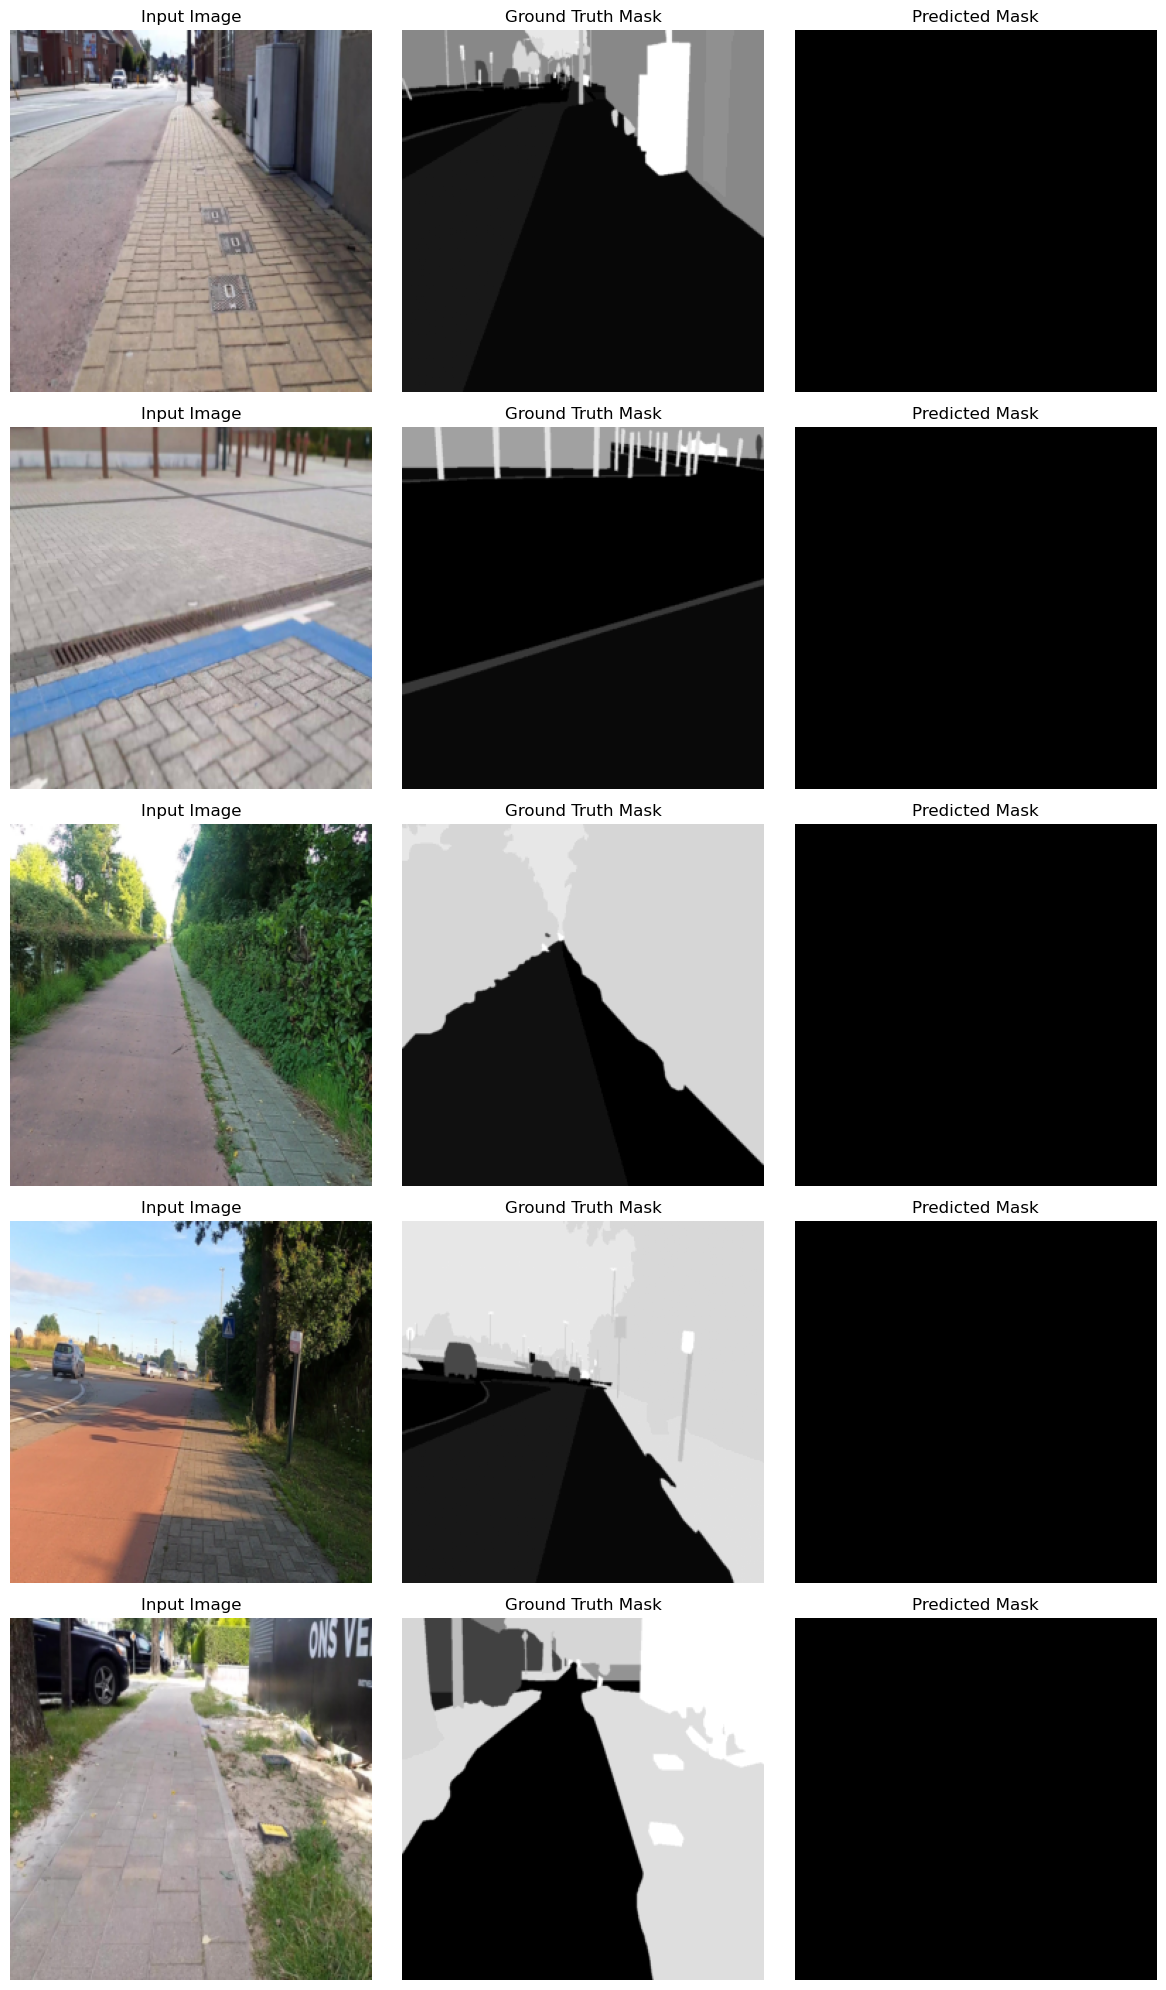

In [47]:
# Example usage
visualize_predictions(model, dataloader, device=device, num_samples=5)